# What actually couples the darts of a visit

Notebook 19 found the project's oldest assumption failing: the three darts of a visit are not
independent draws. Hitting the treble 20 raised the next dart's chance of doing the same by
18 points. This notebook asks the follow-up question, which is the one that changes the code:
**what should replace the assumption?**

> **Amended after notebook 21.** This notebook originally reported a second finding: that a
> single dart's Gaussian tails were far too thin, worth five log-likelihood units a visit.
> That rested on a defect in the 2017 feed, which carries the previous leg's finishing darts
> into the next leg's opening visit -- and since every visit with 430 or more remaining is
> near a leg start, that visit was most of this sample. Everything below is **refitted on the
> cleaned data** (`darts.real_data`). The aim-rule results are unchanged. The tail is much
> smaller than reported, and notebook 21 shows a **Student-t** describes what remains better
> than the wide component used here.

The answer turns out to require unpicking that 18 points first, because it is not one effect.
Three separate things are mixed into it, and only the third is about the throw at all:

1. **The aim moves.** A player who misses the treble 20 often works *down* the board -- to
   the 19, then the 18, then the 17. After a miss, the next dart is frequently not *aimed* at
   the treble 20, so of course it hits it less often. This is a decision, and the model has no
   state for it: in this project the aim point depends on the score and the dart index, and
   never on where the previous dart landed.
2. **One dart's distribution is not Gaussian.** A Gaussian cannot be tight enough to hit the
   treble 20 at a professional rate and still reach the beds either side of the 20 as often as
   real players do.
3. **Whatever is left.** Once the aim and the shape of a dart are in the model, is there any
   coupling between darts remaining -- and if so, what shape?

The method is the same throughout: write the models down first, derive statistics that tell
them apart, check on simulated data that those statistics really do tell them apart, and only
then fit anything real -- on a training split, judged on held-out visits.

In [1]:
import os
import sys
module_path = os.path.abspath(os.path.join('..', '..'))
if module_path not in sys.path:
    sys.path.append(module_path)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.25,
    'grid.linewidth': 0.6, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titlesize': 11, 'font.size': 9, 'legend.frameon': False,
})

from darts.dependence import (BedGrid, VisitModel, encode_visits, signatures,
                              treble_centre_mm, TARGETS)
# This notebook originally built its own filter inline, and so did notebook 19.
# They agreed with each other and were both wrong in the same way: the 2017 feed
# carries the previous leg's finishing darts into the next leg's opening visit,
# and every visit with 430 or more remaining is near a leg start, so that visit
# was 78% of the sample. Notebook 21 found it. The one definition now lives in
# darts.real_data, and everything below is refitted on the cleaned data.
from darts.real_data import DATA, load_darts, scoring_visits

RES = os.path.join(module_path, 'results', 'dependence')
if not os.path.exists(os.path.join(DATA, 'per_dart.csv')):
    raise SystemExit('run scripts/build_real_data.py first (see data/real/README.md)')

GRID = BedGrid(512)
KEY = ['source', 'player', 'leg_id', 'visit_index']

scoring = load_darts()
VIS = scoring_visits(scoring, clean=True)
print(f'{len(VIS):,} clean pure-scoring visits, {VIS.player.nunique()} players')

24,608 clean pure-scoring visits, 158 players


## 1 · The aim moves

The tell is the treble 19. It sits eleven segments from the treble 20, on the opposite side of
the board -- no dart aimed at one can land in the other by accident. So a dart near the 19 is
direct evidence of where it was *aimed*, which is the one thing a scoresheet normally cannot
give us. The same argument extends to the 18 and the 17, and it turns out all four are needed.

A dart is assigned to a target when it lands within one segment of it, which leaves about 1%
of darts unassigned rather than forcing them somewhere.

In [2]:
from darts.dependence import BOARD_ORDER

def nearest_target(bed):
    # which target a dart was aimed at, when it landed within one segment
    if bed in ('MISS', '25', 'BULL'):
        return None
    number = int(bed[1:])
    best, best_d = None, 99
    for t in TARGETS:
        d = abs((BOARD_ORDER.index(number) - BOARD_ORDER.index(t) + 10) % 20 - 10)
        if d < best_d:
            best, best_d = t, d
    return best if best_d <= 1 else None

for i in (1, 2, 3):
    VIS[f'aim{i}'] = VIS[i].map(nearest_target)

print('which target each dart was thrown at, by position in the visit:')
share = pd.DataFrame({f'dart {i}': VIS[f'aim{i}'].value_counts(normalize=True,
                                                               dropna=False)
                      for i in (1, 2, 3)}).fillna(0.0)
share.index = [('unassigned' if pd.isna(i) else f'the {int(i)}') for i in share.index]
print(share.round(3).to_string())

print('\nwhere the next dart goes, given the one before it:')
rows = []
for frm in TARGETS:
    for hit_it, label in [(True, 'hit the treble'), (False, 'missed')]:
        m = pd.concat([
            VIS[(VIS[f'aim{d}'] == frm)
                & (VIS[d].str.startswith('T') == hit_it)
                & VIS[f'aim{d + 1}'].notna()].rename(
                    columns={f'aim{d + 1}': 'next'})[['next']]
            for d in (1, 2)])
        if len(m) < 100:
            continue
        row = {'from': f'the {frm}', 'after': label, 'n': len(m)}
        row.update({f'-> {int(t)}': (m['next'] == t).mean() for t in TARGETS})
        rows.append(row)
pd.DataFrame(rows).set_index(['from', 'after']).round(3)

which target each dart was thrown at, by position in the visit:


            dart 1  dart 2  dart 3
the 17       0.000   0.000   0.021
the 18       0.000   0.004   0.054
the 19       0.002   0.189   0.245
the 20       0.998   0.802   0.673
unassigned   0.000   0.004   0.008

where the next dart goes, given the one before it:


n  -> 20  -> 19  -> 18  -> 17
from   after                                            
the 20 hit the treble  17873  0.951  0.046  0.001  0.002
       missed          26176  0.726  0.249  0.008  0.016
the 19 hit the treble   1894  0.015  0.924  0.058  0.002
       missed           2791  0.067  0.549  0.368  0.016

The aim is not fixed, and it is not even two targets. Professionals use **four** and work
down them.

Dart 1 is at the 20 essentially always -- **99.8%**. By dart 3 the 20 holds only **67.3%**,
with **24.5%** at the 19, 5.4% at the 18 and 2.1% at the 17.

The transitions say why, and they are almost all **one step down**. From the 20, a dart that
hits the treble is followed by another at the 20 **95.1%** of the time; a dart that misses is
followed by one at the 19 **24.9%** of the time. From the 19 the same pattern repeats one place
along: stay 92.4% after a hit, move to the 18 **36.8%** after a miss.

So the rule is simple enough to write in one line -- *stay if you hit, else you may step one
place down* -- and it needs exactly two numbers. What it does not fit into is this project's
solver, where the aim point is a function of the score and the dart index and nothing else.
There is no state for "where did my last dart land".

In [3]:
def lift(a, b):
    h, m = b[a == 1].mean(), b[a == 0].mean()
    n1, n0 = int((a == 1).sum()), int((a == 0).sum())
    se = np.sqrt(h * (1 - h) / n1 + m * (1 - m) / n0)
    return 100 * (h - m), 100 * se

t20 = {i: (VIS[i] == 'T20').astype(float) for i in (1, 2, 3)}
treb = {i: VIS[i].str.startswith('T').astype(float) for i in (1, 2, 3)}
rows = [('hit T20 (what notebook 19 measured)', *lift(t20[1], t20[2])),
        ('hit ANY treble (target-invariant)', *lift(treb[1], treb[2]))]
aims = VIS[['aim1', 'aim2', 'aim3']]
pure = VIS[(aims.isin([20]) | aims.isna()).all(axis=1)]
rows.append(('hit T20, visits that never move off the 20',
             *lift((pure[1] == 'T20').astype(float), (pure[2] == 'T20').astype(float))))
out = pd.DataFrame(rows, columns=['dart 1 -> dart 2', 'lift (pts)', 'se'])
out['z'] = out['lift (pts)'] / out.se
out.round(2)

,dart 1 -> dart 2,lift (pts),se,z
0,hit T20 (what notebook 19 measured),21.43,0.64,33.42
1,hit ANY treble (target-invariant),11.53,0.65,17.70
2,"hit T20, visits that never move off the 20",9.04,0.78,11.59


About half of it is the aim, not the throw.

Notebook 19's statistic scores a dart by whether it hit the **treble 20** -- which measures the
throw only if the dart was aimed there. On these visits it reads **+21.43**. Score instead by
whether the dart hit **any** treble, a statistic that does not care which target it was thrown
at, and the same darts give **+11.53**. Restrict to the visits where the player never leaves
the 20, and it is **+9.04**.

All three are overwhelming -- the smallest is z = 11.6 -- so a real coupling survives. But the
headline number is roughly **twice** the part of it that is about throwing, and the difference
is a decision the player made, not a property of their throw.

Notebook 19's three robustness checks did not miss this through weakness. Pooling, drift and
selection were each ruled out properly. Switching target is a within-visit, within-player
effect that vanishes across the gap between visits, so it passes all three -- it is the
alternative that was not thought of, which is a different kind of gap from one that was tested
and survived.

Before building anything on that, it is worth checking it is not an artefact of one feed's
coding. Two things to confirm: that the bed labels agree with the scores recorded alongside
them, and that the pattern appears in *both* independent sources -- different providers,
different years, different tournaments.

In [4]:
def bed_value(name):
    if name == 'MISS':
        return 0
    if name == '25':
        return 25
    if name == 'BULL':
        return 50
    return int(name[1:]) * {'S': 1, 'D': 2, 'T': 3}[name[0]]

check = scoring.dropna(subset=['bed']).copy()
check['implied'] = check.bed.map(bed_value)
mismatch = int((check.implied != check.value).sum())
print(f'darts whose bed disagrees with the score recorded beside it: '
      f'{mismatch} of {len(check):,} ({100 * mismatch / len(check):.3f}%)')

rows = []
for src, g in VIS.groupby('source'):
    hit = g[g[1] == 'T20']
    miss = g[(g.aim1 == 20) & (g[1] != 'T20')]
    if len(miss) < 50:
        continue
    rows.append({'source': src, 'visits': len(g),
                 'dart 1 at the 19': (g.aim1 == 19).mean(),
                 'dart 3 below the 20': (g.aim3.isin([19, 18, 17])).mean(),
                 'stays after a hit': (hit.aim2 == 20).mean(),
                 'moves after a miss': (miss.aim2 != 20).mean()})
pd.DataFrame(rows).set_index('source').round(3)

darts whose bed disagrees with the score recorded beside it: 42 of 300,822 (0.014%)


,visits,dart 1 at the 19,dart 3 below the 20,stays after a hit,moves after a miss
source,,,,,
dartsviz_pdc_2017,20583,0.002,0.311,0.970,0.277
sportradar_pdc_wc_2022,4025,0.002,0.363,0.979,0.327


It is not a coding artefact.

The bed labels agree with the scores recorded beside them for all but **42 darts in 300,822**
-- 0.014%. The build script gates on exactly this, so a feed that disagreed with itself would
have stopped the rebuild rather than reached here.

(That gate is worth noting for what it did *not* catch. Every bed here is internally
consistent with its own score, and the leg boundaries are still wrong -- see notebook 21. A
consistency check covers what it is pointed at and nothing else.)

More importantly, the pattern appears in **both** sources: different commercial providers,
different years, different tournaments. The share of first darts at the 19 (0.002 in both), of
third darts below the 20 (0.311 and 0.363), of staying after a hit (0.970 and 0.979) and of
moving after a miss (0.277 and 0.327) all agree closely. Two feeds five years apart do not
invent the same behaviour.

### Does the switch cost them anything?

Notebook 18 established that above a remaining score of 250 the treble 20 is the optimal aim
for every ability the model covers -- that is what makes the whole scoring-phase analysis
possible. So the model says this switch is a mistake. The data can price it.

The comparison has to be made **within a player**, since players differ both in how often they
switch and in how well they throw. And it is observational, not causal: a player decides to
switch knowing things about the dart that just landed which the bed label does not record, so
what follows is what switching is *associated* with, not what it *causes*.

In [5]:
from darts.dependence import bed_geometry

# Every bed gets a value and a target, so that nothing is dropped. Excluding the
# beds that sit near neither target would be selecting on dart 2's *outcome* --
# and the beds it would exclude are the worst darts, which is exactly the
# comparison being made. Instead each dart is assigned to whichever target it is
# angularly nearer, the same rule the signature statistics use.
angle, _ = bed_geometry(GRID)
stack = np.stack([angle[t] for t in TARGETS])
nearest = np.argmin(np.where(np.isnan(stack), np.inf, np.abs(stack)), axis=0)
aimed_at = {n: TARGETS[nearest[i]] for i, n in enumerate(GRID.names)}

missed = VIS[(VIS.aim1 == 20) & (VIS[1] != 'T20')].copy()
missed['score2'] = missed[2].map(bed_value)
missed['moved'] = missed[2].map(aimed_at) != 20     # every dart gets a target
assert missed.score2.notna().all()

rows = []
for (src, pl), g in missed.groupby(['source', 'player']):
    stay, move = g[~g.moved], g[g.moved]
    if min(len(stay), len(move)) < 40:
        continue
    diff = move.score2.mean() - stay.score2.mean()
    se = np.sqrt(move.score2.var() / len(move) + stay.score2.var() / len(stay))
    rows.append({'player': pl, 'n stay': len(stay), 'n move': len(move),
                 'stayed at 20': stay.score2.mean(), 'moved down': move.score2.mean(),
                 'diff': diff, 'se': se})
cost = pd.DataFrame(rows).sort_values('diff')
w = 1 / cost.se ** 2
print(f'{len(cost)} players with at least 40 of each')
print(f'pooled difference in dart-2 score, moving vs staying: '
      f'{(w * cost["diff"]).sum() / w.sum():+.2f} +/- {np.sqrt(1 / w.sum()):.2f} points')
print(f'players where moving scored less: {(cost["diff"] < 0).sum()} of {len(cost)}')
cost.round(2).head(10)

29 players with at least 40 of each
pooled difference in dart-2 score, moving vs staying: -0.37 +/- 0.47 points
players where moving scored less: 15 of 29


,player,n stay,n move,stayed at 20,moved down,diff,se
22,Phil Taylor,336,56,37.92,28.57,-9.35,2.75
10,Ian White,178,60,33.88,28.90,-4.98,2.80
15,Kyle Anderson,135,77,35.44,30.90,-4.55,2.87
18,Mervyn King,140,47,37.71,33.53,-4.18,3.39
1,Alan Norris,212,58,33.35,29.55,-3.80,2.77
2,Benito van de Pas,158,65,33.67,31.12,-2.55,3.00
24,Rob Cross,154,100,34.77,33.14,-1.63,2.55
23,Raymond van Barneveld,439,63,35.05,33.54,-1.51,2.72
12,Jelle Klaasen,153,210,32.05,30.58,-1.48,2.14
9,Gerwyn Price,235,118,34.71,33.83,-0.88,2.31


In [6]:
# what the model says the switch should cost, for comparison
vals = np.array([bed_value(n) for n in GRID.names], float)
rows = []
for sigma in (5.0, 6.5, 8.0, 10.0, 13.0, 16.0):
    p = {t: 0.87 * GRID.bed_pmf(t, np.zeros(2), sigma)
            + 0.13 * GRID.wide_pmf(t, sigma * 6) for t in TARGETS}
    rows.append({'sigma (mm)': sigma,
                 'E[score] at T20': p[20] @ vals, 'E[score] at T19': p[19] @ vals,
                 'cost of switching': (p[19] @ vals) - (p[20] @ vals),
                 'P(T20)': p[20][GRID.names.index('T20')],
                 'P(T19)': p[19][GRID.names.index('T19')]})
print('the 20 is flanked by the 1 and the 5 (mean 3); the 19 by the 3 and the 7 (mean 5)')
pd.DataFrame(rows).set_index('sigma (mm)').round(2)

the 20 is flanked by the 1 and the 5 (mean 3); the 19 by the 3 and the 7 (mean 5)


,E[score] at T20,E[score] at T19,cost of switching,P(T20),P(T19)
sigma (mm),,,,,
5.0,39.10,37.38,-1.72,0.50,0.51
6.5,34.62,33.16,-1.47,0.40,0.40
8.0,31.01,29.80,-1.21,0.32,0.32
10.0,26.97,26.11,-0.86,0.24,0.24
13.0,22.30,21.92,-0.39,0.17,0.17
16.0,18.97,18.95,-0.02,0.12,0.12


Almost nothing, and the board's numbering is why.

Pooled within player, moving down after a miss is worth **-0.37 +/- 0.47 points** on the next
dart -- indistinguishable from zero, with 15 of 29 players scoring less and 14 more. The model
expects it to cost 1.2 to 1.5 points at a professional's spread, so the observed cost is if
anything *smaller* than predicted.

The reason the cost is so small is in the second table. A treble 19 is worth three points less
than a treble 20, but the 20 is flanked by the **1 and the 5** and the 19 by the **3 and the
7**. Missing the 19 sideways pays a mean of 5 where missing the 20 pays 3, and that nearly
cancels the treble being smaller. At a 16 mm spread it cancels exactly.

This is a habit the model calls a mistake, performed by the best players in the world, that
costs them close to nothing. It is also a hint about *why* they do it, since the model can see
no reason at all: what changes between dart 1 and dart 2 is that there is now a dart in the
board, and nothing in this project represents that.

## 2 · One dart is not Gaussian

The second thing the data forces into the model has nothing to do with dependence. Take the
player with the most clean scoring visits and look at where his *first* dart goes -- the one
dart we can be sure was aimed at the treble 20.

> Read this section with notebook 21 alongside. As originally written it rested on double 20s
> and off-board misses that turned out to be leaked checkout darts, and it drew the wrong
> conclusion about *how* a dart departs from a Gaussian. On the cleaned data below the
> departure is real but nearer in, and notebook 21 identifies it as a Student-t rather than
> the mixture fitted here.

In [7]:
who = VIS.groupby(['source', 'player']).size().idxmax()
sub = VIS[(VIS.source == who[0]) & (VIS.player == who[1])]
beds, hit = encode_visits(sub[[1, 2, 3]].values, GRID)
obs = np.bincount(beds[:, 0], minlength=GRID.n_beds) / len(beds)
top = np.argsort(obs)[::-1][:8]

rows = {'OBSERVED (dart 1)': obs[top]}
for sigma in (6.5, 8.0, 11.0, 14.5):
    rows[f'gaussian {sigma} mm'] = GRID.bed_pmf(20, np.zeros(2), sigma)[top]
tail = pd.DataFrame(rows, index=[GRID.names[i] for i in top]).T
print(f'{who[1]}: {len(beds):,} visits')
tail.round(4)

Peter Wright: 1,303 visits


,S20,T20,S1,T1,S5,T5,S19,T19
OBSERVED (dart 1),0.5434,0.3784,0.0253,0.0192,0.0184,0.0115,0.0023,0.0008
gaussian 6.5 mm,0.5332,0.4537,0.0035,0.0031,0.0035,0.0031,0.0000,0.0000
gaussian 8.0 mm,0.5915,0.3646,0.0135,0.0084,0.0135,0.0084,0.0000,0.0000
gaussian 11.0 mm,0.6147,0.2424,0.0511,0.0203,0.0511,0.0203,0.0000,0.0000
gaussian 14.5 mm,0.5747,0.1588,0.1037,0.0289,0.1037,0.0289,0.0000,0.0000


A Gaussian cannot do both ends at once.

The player hits the treble 20 **37.8%** of the time. A 6.5 mm Gaussian reproduces that rate
about right -- 45.4%, a little high -- and then puts **0.35%** in the single 1 and 0.35% in the
single 5, where he really lands **2.53%** and **1.84%**. It is too tight in the shoulders by a
factor of seven.

Widening it does not rescue anything, it trades one end for the other. By 11 mm the single 1
and single 5 are about right (5.1% each, against 2.5% and 1.8% observed -- now too *high*), and
the treble rate has collapsed to 24%. By 14.5 mm the treble is at 16% against 38% observed.
There is no single width that is sharp in the middle and generous in the shoulders, because a
Gaussian has one parameter and this shape needs two.

Fitted with no way out, the optimiser splits the difference and lands wide -- which is why a
naive fit reports professionals throwing far more loosely than they do. The repair used below
is a contaminating component: most darts from a tight throw, a small fraction from something
broader. It works, and notebook 21 shows it is not the best answer -- a **Student-t**, which is
one parameter rather than two, fits the same shape better.

In [8]:
core = GRID.bed_pmf(20, np.zeros(2), 6.9)
wide = GRID.wide_pmf(20, 6.9 * 6.0)
mix = 0.87 * core + 0.13 * wide
comp = pd.DataFrame({'OBSERVED': obs[top], 'gaussian 6.9 mm': core[top],
                     '87% core + 13% wide': mix[top]},
                    index=[GRID.names[i] for i in top]).T
comp.round(4)

,S20,T20,S1,T1,S5,T5,S19,T19
OBSERVED,0.5434,0.3784,0.0253,0.0192,0.0184,0.0115,0.0023,0.0008
gaussian 6.9 mm,0.5530,0.4275,0.0054,0.0043,0.0054,0.0043,0.0000,0.0000
87% core + 13% wide,0.5122,0.3750,0.0278,0.0060,0.0278,0.0060,0.0000,0.0000


## 3 · The model family

Six models, each adding one mechanism to the last, so that every comparison isolates one
thing. All of them keep the throw isotropic: notebook 12 showed shape matters, but letting it
vary here would confound the question being asked.

| | mechanism added | what it says |
|---|---|---|
| **A** | -- | one target, Gaussian, independent darts. **What the project assumes today** |
| **B** | the aim rule | after a miss the player may move to the treble 19 |
| **C** | a wide component | a fraction `eps` of darts come from a much wider throw |
| **D** | a shared **offset** | the visit's aim point is drawn once: darts cluster in *direction* |
| **E** | a shared **scale** | the visit is tight or loose: darts agree in *magnitude* only |

A sixth model with both couplings at once was fitted and dropped: on the few hundred visits one
player supplies, eight parameters are not identified -- the optimiser puts half the darts in
the wide component, collapses `sigma` to 2.7mm, and scores *worse* on held-out visits than
either coupling alone. That is a fact about the sample size, not about the mechanism.

D and E are the two simple ways to break independence, and they are not the same story. D is
"he had that stance for those three darts". E is "he was in the groove that visit". They make
different, checkable predictions, which is the next section.

Everything is fitted to *bed sequences* by exact maximum likelihood. The per-visit latent is
integrated out by Gauss-Hermite quadrature; the latent target of each dart is summed out
exactly with a two-state forward pass, which is cheap because a visit is three darts long.

### The statistics that tell D from E

Pre-specified, before any fitting, and computed by one function applied identically to real
visits and to simulated ones.

* **`dir_corr`** -- the correlation between the *signed* angular offsets of two darts in a
  visit, measured in segments from whichever target they were thrown at. A shared offset
  pushes a whole visit one way round the board, so this is positive. A shared scale has no
  preferred direction, so this is zero.
* **`mag_corr`** -- the same for *absolute* offsets. Both models make this positive.

So the ratio separates them: D couples direction and magnitude about equally, E couples
magnitude only. Before trusting that, it has to be shown on data where the truth is known.

In [9]:
rng = np.random.default_rng(0)
spec = {'M0 independent': dict(switching=True),
        'M1 shared offset': dict(shared_offset=True, switching=True),
        'M2 shared scale': dict(shared_scale=True, switching=True)}
truth = {'M0 independent': [np.log(8.6), 0.0, -3.5, -1.0],
         'M1 shared offset': [np.log(7.0), 0.0, np.log(5.0), -3.5, -1.0],
         'M2 shared scale': [np.log(8.35), 0.0, np.log(0.42), -3.5, -1.0]}

rows = []
for name, kw in spec.items():
    m = VisitModel(GRID, **kw)
    b, h = m.simulate(np.array(truth[name]), 12000, rng=rng)
    s = signatures(b, h, GRID)
    rows.append({'simulated from': name, 'P(T20)': s['p_t20'],
                 'T20 lift 1->2': s['t20_lift_12'],
                 'treble lift 1->2': s['treble_lift_12'],
                 'dir_corr': s['dir_corr'], 'mag_corr': s['mag_corr']})
pd.DataFrame(rows).set_index('simulated from').round(3)

,P(T20),T20 lift 1->2,treble lift 1->2,dir_corr,mag_corr
simulated from,,,,,
M0 independent,0.272,7.856,-0.679,-0.001,-0.000
M1 shared offset,0.278,8.639,0.621,0.049,0.078
M2 shared scale,0.335,18.532,10.283,-0.006,0.123


The two statistics do what they were designed to do.

Simulated from a **shared offset**, `dir_corr` is **+0.049** and `mag_corr` **+0.078** -- the
darts of a visit agree about direction and about distance roughly equally, because they share a
displacement. Simulated from a **shared scale**, `dir_corr` is **-0.006** and `mag_corr`
**+0.123**: the darts agree about how far out they are and not at all about which way, because
nothing has moved the aim. Simulated from **independent** darts, both are zero.

So the *ratio* separates the two mechanisms cleanly even though either one alone raises the
treble-20 lift. That is what makes the check on real data in section 5 worth running.

Note also the first row. Independent darts, with nothing coupling them, still produce a
treble-20 lift of **+7.9** -- purely from the aim rule. Any measurement of within-visit
dependence that does not model where the dart was aimed is measuring this as well.

## 4 · The fits

`scripts/dependence_fits.py` fits all six models to every player with at least 400 clean
scoring visits. The split is on whole **legs**, not visits -- visits inside a leg share a
player, an evening and a scoreline, so splitting on visits would leak information across the
boundary. Both halves contain the same players by design: the question is whether a model
generalises to new visits, not to new people.

Models are scored by held-out log-likelihood per visit, which needs no penalty term because
the parameters were never fitted to the visits doing the scoring.

In [10]:
# What model A -- the project's current assumption -- makes of real darts.
# With one fixed target it has no way to produce a dart at the 19 at all, so the
# question is not how well it fits but how much of the data it calls impossible.
impossible = np.mean([(VIS[f'aim{i}'].isin([19, 18, 17])).mean() for i in (2, 3)])
p20 = GRID.bed_pmf(20, np.zeros(2), 13.1)
print('darts 2 and 3 thrown below the 20: %.1f%% of them' % (100 * impossible))
print('probability model A gives a dart at the S19: %.3g' % p20[GRID.names.index('S19')])
print('\nso model A is not merely a worse fit -- it assigns essentially zero')
print('probability to a fifth of the darts professionals actually throw.')

darts 2 and 3 thrown below the 20: 25.7% of them
probability model A gives a dart at the S19: 0

so model A is not merely a worse fit -- it assigns essentially zero
probability to a fifth of the darts professionals actually throw.


In [11]:
fits = pd.read_csv(os.path.join(RES, 'fits.csv'))
sigs = pd.read_csv(os.path.join(RES, 'signatures.csv'))
print(f'{fits.player.nunique()} players, {fits.model.nunique()} models, '
      f'{fits.n_train.sum():,} training and {fits.n_test.sum():,} held-out visits')

# Model A is quoted separately below. Its log-likelihood is not a measure of
# fit but of impossibility: with no aim rule it gives every dart at the 19 a
# probability of zero, so its value is set by the numerical floor rather than by
# anything about the player. The ladder is therefore baselined on B.
base = (fits[fits.model == 'B + aim rule']
        .set_index(['source', 'player']).test_ll_per_visit)
fits['gain'] = fits.apply(
    lambda r: r.test_ll_per_visit - base.loc[(r.source, r.player)], axis=1)
ladder = fits.groupby('model').agg(
    players=('player', 'size'),
    gain=('gain', 'mean'),
    worst=('gain', 'min'),
    best=('gain', 'max'),
    sigma=('sigma', 'median'), tau=('tau', 'median'), nu=('nu', 'median'),
    eps=('eps', 'median'), s_miss=('s_miss', 'median')).round(4)
ladder

17 players, 5 models, 27,145 training and 27,345 held-out visits


,players,gain,worst,best,sigma,tau,nu,eps,s_miss
model,,,,,,,,,
A gaussian iid,17,-225.1002,-382.7971,-101.6997,9.3007,0.000,0.00,0.0000,0.0000
B + aim rule,17,0.0000,0.0000,0.0000,10.9509,0.000,0.00,0.0000,0.3040
C + wide tail,17,2.1537,0.0699,12.7170,6.4223,0.000,0.00,0.0929,0.3061
D + shared offset,17,2.1637,0.0728,12.7141,4.7316,4.307,0.00,0.1040,0.3062
E + shared scale,17,2.1741,0.0601,12.7342,7.0100,0.000,0.28,0.0653,0.3035


Three mechanisms, three very different sizes.

**The aim rule is the big one, and its number should not be read as a likelihood ratio.**
Model A cannot produce a dart at the 19 at all, so what it reports is not a poor fit but an
impossible one -- its value is set by the numerical floor, and the honest statement is the
qualitative one above: the project's current model gives essentially zero probability to a
quarter of the darts professionals throw after the first one of a visit. The ladder is therefore
quoted from B.

**One dart's shape is the second.** Adding a wide component buys **2.15 log-likelihood units
per visit** on average and improves all 17 players. But read the median too -- **0.53** -- and
the range, which runs from 0.07 to 12.7. The mean is carried by a few players; for half of them
this is worth about half a unit. (Before the leg-boundary defect was found the same step read
5.13, with a median of 5.59. Removing the leaked darts cut the median by 90%, which is the
clearest single measure of how much of this was contamination.)

It still rescues `sigma`: model B, with no way to explain a dart in the shoulders, inflates the
spread to a median of **11.0 mm**; model C recovers **6.4 mm**, which is where professionals
should be. A fit that ignores the shape of a dart reports the best players in the world
throwing far more loosely than they do.

**The dependence is the third, and on this measure it is small.** A per-visit location offset
adds **0.010** a visit and helps 13 of 17 players; a per-visit *scale* adds **0.020** and helps
15 of 17, winning outright on 11. Both are marginal here -- whether this is the right measure
of them is section 6.

In [12]:
step = {'C + wide tail': 'B + aim rule',
        'D + shared offset': 'C + wide tail', 'E + shared scale': 'C + wide tail'}
piv = fits.pivot_table(index=['source', 'player'], columns='model',
                       values='test_ll_per_visit')
rows = []
for model, prev in step.items():
    delta = piv[model] - piv[prev]
    rows.append({'step': f'{prev.split()[0]} -> {model.split()[0]}',
                 'adds': model.split(' ', 1)[1],
                 'mean gain': delta.mean(), 'median': delta.median(),
                 'players improved': f'{(delta > 0).sum()} / {len(delta)}'})
pd.DataFrame(rows).round(4)

,step,adds,mean gain,median,players improved
0,B -> C,+ wide tail,2.1537,0.5339,17 / 17
1,C -> D,+ shared offset,0.0100,0.0033,13 / 17
2,C -> E,+ shared scale,0.0204,0.0125,15 / 17


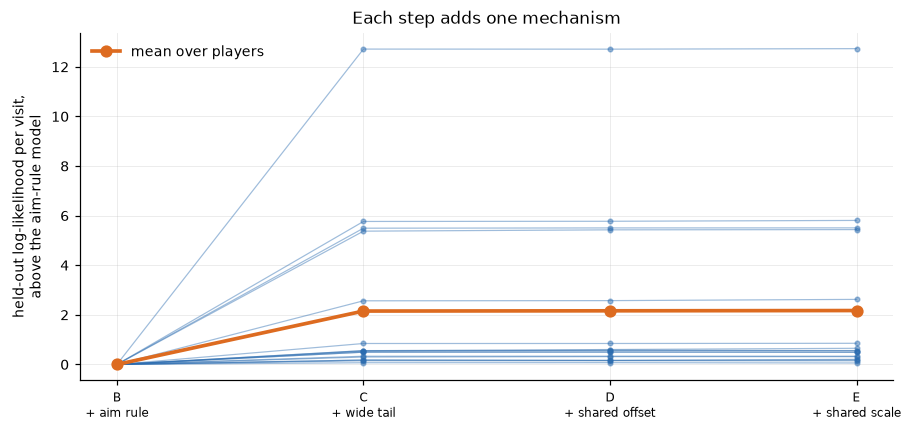

In [13]:
fig, ax = plt.subplots(figsize=(8.4, 4.0))
order = ['B + aim rule', 'C + wide tail',
         'D + shared offset', 'E + shared scale']
for (src, pl), g in fits.groupby(['source', 'player']):
    g = g.set_index('model').reindex(order)
    ax.plot(range(len(order)), g.gain.values, marker='o', ms=3, lw=0.8,
            alpha=0.45, color='#2b6cb0')
mean = fits.groupby('model').gain.mean().reindex(order)
ax.plot(range(len(order)), mean.values, marker='o', ms=7, lw=2.4,
        color='#dd6b20', label='mean over players', zorder=5)
ax.set_xticks(range(len(order)))
ax.set_xticklabels([o.replace(' + ', '\n+ ') for o in order], fontsize=8)
ax.set_ylabel('held-out log-likelihood per visit,\nabove the aim-rule model')
ax.set_title('Each step adds one mechanism')
ax.legend()
fig.tight_layout()

## 5 · Does the winning model reproduce what the data does?

A better likelihood is not the same as a model that behaves like a darts player. The check is
the pre-specified signatures: draw visits from each fitted model and ask whether they show
what the real visits show. Nothing here was fitted to these statistics.

In [14]:
cols = ['p_t20', 't20_lift_12', 'treble_lift_12', 'dir_corr', 'mag_corr', 'switch_rate']
w = sigs.groupby(['model'])[cols].mean()
n_obs = sigs[sigs.model == 'OBSERVED'].set_index(['source', 'player']).n
# model A included here even though the likelihood ladder excludes it: its
# likelihood is meaningless (see above) but its *predictions* are not, and it is
# the model the project currently uses
tab = w.reindex(['OBSERVED', 'A gaussian iid'] + order)
tab.round(3)

,p_t20,t20_lift_12,treble_lift_12,dir_corr,mag_corr,switch_rate
model,,,,,,
OBSERVED,0.336,21.120,9.775,0.022,0.021,0.198
A gaussian iid,0.318,-0.126,-0.126,0.001,-0.003,0.000
B + aim rule,0.208,5.745,-0.326,-0.001,-0.004,0.228
C + wide tail,0.326,9.411,0.502,-0.000,-0.005,0.204
D + shared offset,0.333,15.748,7.353,0.012,0.025,0.203
E + shared scale,0.340,13.961,4.916,0.000,0.034,0.200


Here the small numbers turn out to matter.

Held-out likelihood said the coupling was worth 0.02 a visit. But the statistic notebook 19
actually reported -- the treble-20 lift from dart 1 to dart 2 -- is **21.1 points** in these
players' held-out visits, and the models reproduce it in a ladder: **-0.1** with no aim rule,
**5.7** with the aim rule, **9.4** once one dart's shape goes in, **15.7** with a shared offset
and **14.0** with a shared scale.

So the mechanisms are not competing to explain the same thing. The aim rule and the dart's
shape buy almost all of the likelihood, because they govern where single darts go, which is
most of what a bed sequence tells you. The coupling buys almost none of it and yet is most of
what reproduces the *correlation* -- a bed is a coarse observation and a visit is only three
darts long, so a per-visit effect leaves little fingerprint on the likelihood while changing
the correlation substantially. **Choosing a model by held-out likelihood alone would have
understated the one mechanism that matters for the quantity the MDP consumes.**

Note also that none of them reaches the observed 21.1, and that the *offset* model gets closer
than the scale model that wins on likelihood. Whatever the real mechanism is, neither of these
is it.

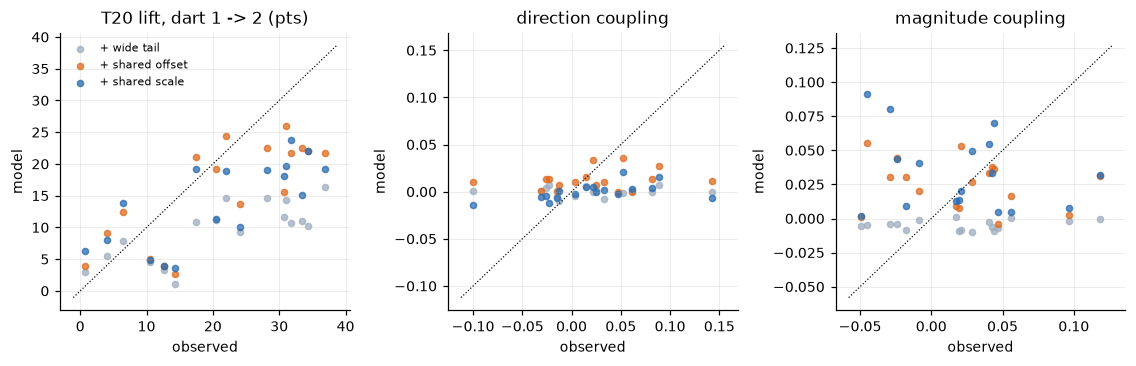

In [15]:
obs_row = sigs[sigs.model == 'OBSERVED'].set_index(['source', 'player'])
fig, axes = plt.subplots(1, 3, figsize=(10.4, 3.4))
for ax, stat, title in zip(axes,
                           ['t20_lift_12', 'dir_corr', 'mag_corr'],
                           ['T20 lift, dart 1 -> 2 (pts)',
                            'direction coupling', 'magnitude coupling']):
    for model, colour in [('C + wide tail', '#a0aec0'), ('D + shared offset', '#dd6b20'),
                          ('E + shared scale', '#2b6cb0')]:
        m = sigs[sigs.model == model].set_index(['source', 'player'])
        common = obs_row.index.intersection(m.index)
        ax.scatter(obs_row.loc[common, stat], m.loc[common, stat], s=16,
                   alpha=0.75, color=colour, label=model.split(' ', 1)[1])
    lo = min(ax.get_xlim()[0], ax.get_ylim()[0])
    hi = max(ax.get_xlim()[1], ax.get_ylim()[1])
    ax.plot([lo, hi], [lo, hi], color='k', lw=0.8, ls=':')
    ax.set_xlabel('observed'); ax.set_ylabel('model'); ax.set_title(title)
axes[0].legend(fontsize=7)
fig.tight_layout()

In [16]:
best = fits.loc[fits.groupby(['source', 'player']).test_ll_per_visit.idxmax()]
print('model chosen per player, by held-out likelihood:')
print(best.model.value_counts().to_string())

win = fits[fits.model == 'E + shared scale'].copy()
# kappa is the wide component's width as a multiple of the core. Once eps is
# small it stops being identified from above: past roughly the radius of the
# board the wide component is just "somewhere on the board", and every larger
# value fits identically. Report the width in millimetres and say which players
# ran off the end rather than printing a number like 1e134.
win['wide sd (mm)'] = win.sigma * win.kappa
unbounded = win['wide sd (mm)'] > 225.5
print(f'\nwide component wider than the board, so its width is not identified: '
      f'{int(unbounded.sum())} of {len(win)} players')
win.loc[unbounded, 'wide sd (mm)'] = np.inf
print(f'players pulling towards the 5 (negative): '
      f'{int((win.bias_x < 0).sum())} of {len(win)};  median {win.bias_x.median():+.2f} mm')
show = win[['player', 'n_train', 'sigma', 'bias_x', 'nu', 'eps', 'wide sd (mm)',
            's_hit', 's_miss']]
print(show.sort_values('n_train', ascending=False).round(3).to_string(index=False))

model chosen per player, by held-out likelihood:
model
E + shared scale     11
D + shared offset     6

wide component wider than the board, so its width is not identified: 1 of 17 players
players pulling towards the 5 (negative): 12 of 17;  median -1.59 mm
               player  n_train  sigma  bias_x    nu   eps  wide sd (mm)  s_hit  s_miss
         Peter Wright      650  6.471  -1.595 0.222 0.123        29.167  0.018   0.138
   Michael van Gerwen      530  5.477  -4.956 0.214 0.061        26.614  0.094   0.417
Raymond van Barneveld      389  7.461  -3.504 0.125 0.036           inf  0.026   0.115
         Daryl Gurney      367  6.360  -5.024 0.288 0.088        35.102  0.005   0.243
        Gary Anderson      348  6.659  -1.044 0.414 0.089        32.469  0.084   0.314
          Phil Taylor      338  6.893  -5.296 0.241 0.025        26.700  0.143   0.203
        Dave Chisnall      307  7.659   1.250 0.483 0.052        46.207  0.026   0.303
         Gerwyn Price      285  6.203  -3.725 

The winning model, per player, and what it says about them.

The median professional here throws with `sigma` **7.0 mm**, puts about **6.5%** of darts in a
wide component, moves off the 20 after **30%** of misses and **3%** of hits, and has a
per-visit scale of `nu` **0.28**. That is not a small description of a player, however small
its contribution to the likelihood was.

They also **pull sideways**, by a median of **1.6 mm** and as much as 5 mm, and mostly the same
way: **12 of 17** pull towards the 5, which is the left side of the board as you face it. The
fit is not inventing this -- the per-player estimates correlate at 0.87 with the raw asymmetry
between the beds either side of the 20, and the board's segment boundaries were checked to be
exactly symmetric about the 20 before this was believed. Notebook 13 found a pull the most
expensive thing to get wrong, and notebook 18 found the sideways component the only one a
scoresheet measures well; this is that measurement, on real players.

Two honest caveats sit in this table. The width of the wide component is **not identified from
above**: once `eps` is small, anything broader than the board fits identically, and for one
player of seventeen the fit still runs off the end. (On the contaminated data it was seven of
nineteen -- another sign that most of what this component was fitting has now gone.) And the
throw is held isotropic throughout -- notebook 12 showed that shape matters, but letting it
vary here would have confounded the question the notebook is asking. Notebook 21 tests the
isotropy directly and finds it holds: an elliptical group, given the same one parameter as a
heavy tail, earns nothing.

## 6 · Does the small gain matter for the game?

Held-out log-likelihood on beds is the right way to *choose* between these models, and the
wrong way to decide whether a mechanism matters. A per-visit scale of `nu = 0.4` means a
player's spread wanders by about half again either way from visit to visit -- a large physical
effect -- and it buys very little likelihood, because a bed is a coarse thing to observe and
most of that variation is invisible in it.

The quantity the project actually cares about is the **visit total**: it is what the MDP's
transition matrix is built from, and its spread is what notebook 19 found the model getting
wrong. So the last check is not a likelihood at all. Take each fitted model, draw visits from
it, add up the scores, and compare against what the player really did.

In [17]:
# the fitted models, rebuilt from the stored parameters -- pack() inverts the
# unpack() the fitter uses, so nothing is refitted here
MODEL_KW = {'C + wide tail': dict(switching=True, contamination=True),
            'E + shared scale': dict(switching=True, contamination=True,
                                     shared_scale=True)}

def totals_of(beds):
    value = np.array([bed_value(n) for n in GRID.names])
    return value[beds].sum(axis=1)

rows = []
for (src, pl), sub in VIS.groupby(['source', 'player']):
    got = fits[(fits.source == src) & (fits.player == pl)]
    if got.empty:
        continue
    obs_beds, _ = encode_visits(sub[[1, 2, 3]].values, GRID)
    obs = totals_of(obs_beds)
    rows.append({'player': pl, 'model': 'OBSERVED', 'n': len(obs),
                 'mean': obs.mean(), 'sd': obs.std(),
                 'P(180) %': 100 * (obs == 180).mean(),
                 'P(140+) %': 100 * (obs >= 140).mean(),
                 'P(=60) %': 100 * (obs == 60).mean()})
    for model, kw in MODEL_KW.items():
        r = got[got.model == model].iloc[0]
        m = VisitModel(GRID, n_quad=7, **kw)
        theta = m.pack({'sigma': r.sigma, 'bias': [r.bias_x, 0.0], 'eps': r.eps,
                        'kappa': r.kappa, 'tau': r.tau, 'nu': r.nu,
                        's_hit': r.s_hit, 's_miss': r.s_miss})
        sim_b, _ = m.simulate(theta, 6000, rng=np.random.default_rng(5))
        t = totals_of(sim_b)
        rows.append({'player': pl, 'model': model, 'n': 6000,
                     'mean': t.mean(), 'sd': t.std(),
                     'P(180) %': 100 * (t == 180).mean(),
                     'P(140+) %': 100 * (t >= 140).mean(),
                     'P(=60) %': 100 * (t == 60).mean()})
tot = pd.DataFrame(rows)
cols = ['mean', 'sd', 'P(180) %', 'P(140+) %', 'P(=60) %']
print(f'averaged over the {tot.player.nunique()} players fitted:')
tot.groupby('model')[cols].mean().reindex(['OBSERVED'] + list(MODEL_KW)).round(2)

averaged over the 17 players fitted:


,mean,sd,P(180) %,P(140+) %,P(=60) %
model,,,,,
OBSERVED,104.87,38.41,8.21,28.14,8.39
C + wide tail,103.03,35.57,5.36,24.25,7.65
E + shared scale,104.03,38.27,7.43,26.56,6.59


This is the mechanism's real defence, and it is a strong one.

Both models get the **mean** right, as they must -- it is what `sigma` is fitted to. What
separates them is the **spread**. With independent darts the visit total has a standard
deviation of **35.6** against an observed **38.4**: too narrow, which is exactly the
over-dispersion notebook 19 found and could not explain. Add the per-visit scale and it is
**38.3** -- within half a point of the truth.

The consequence shows up where it is most visible. The independent model predicts a maximum on
**5.36%** of visits against an observed **8.21%** -- **35% too few 180s**. The scale mixture
predicts **7.43%**, within 10% of the truth. P(140+) improves from 24.3 to 26.6 against an
observed 28.1.

So a mechanism worth **0.02 log-likelihood units per visit** -- a rounding error against the
2.15 the dart's shape was worth -- is the difference between getting a professional's 180 rate
wrong by a third and getting it close. Held-out likelihood on beds is a fair way to *rank*
these models and a bad way to decide which of them matters, because it scores what a bed
sequence reveals rather than what the game depends on.

The model still buys its tails slightly too dearly in the middle: P(exactly 60) falls from
7.65 to 6.59 against an observed 8.39.

## Verdict

Notebook 19 measured something real and named it wrongly. Taken apart, the +21 points of
within-visit coupling is three mechanisms, and the smallest of them is the one this project
would have added.

**The aim moves, and that is the largest failure by far.** Professionals use four scoring
targets and step down them after a miss: from the 20, a miss goes to the 19 a quarter of the
time; from the 19 to the 18, better than a third. Dart 1 is at the 20 in 99.8% of visits and
dart 3 in 67.3%. On a target-invariant statistic the coupling drops from +21.4 to +11.5, so
about half of what 19 measured is this. It replicates across two independent feeds five years
apart, and it costs the players nothing measurable (**-0.37 +/- 0.47** points), because the 19
is flanked by the 3 and the 7 where the 20 is flanked by the 1 and the 5.

The important part is not the size but the kind. This is not a missing parameter, it is a
missing **state variable**: the solver's aim point is a function of the score and the dart
index, and there is nowhere to put "where did my last dart land". The current model gives
essentially zero probability to a quarter of the darts thrown after the first of a visit.

**One dart is not Gaussian, though by less than this notebook first reported.** A wide
component buys **2.15 log-likelihood units per visit** on average, improves all 17 players, and
takes a professional's fitted spread from 11.0 mm to 6.4 mm. But the median is **0.53**, so
half the players gain little, and the mean is carried by a few. Notebook 21 takes this further
and lands somewhere else: a **Student-t** beats this mixture using one parameter instead of
two, and the residual after that is smaller again.

**What is left is a shared *scale*, not a shared offset** -- `nu` around 0.28, winning outright
on 11 of 17 players where the offset model wins on 6. On held-out likelihood it is worth almost
nothing, 0.02 a visit; on the quantity the MDP is built from it is worth a great deal. With
independent darts a visit total is too narrow (standard deviation 35.6 against an observed
38.4) and a maximum comes up **35% too rarely**; with the per-visit scale the spread is 38.3
and the 180 rate is within 10%. Both facts are true of the same parameter, which is the
strongest single lesson here: **a bed sequence and a leg of darts do not reward the same
model.**

**And the winning model is visibly the wrong shape.** None of the models reaches the observed
treble-20 lift of 21.1, and the *offset* model -- which loses on likelihood -- comes closer
than the scale model that wins. Whatever couples the darts of a visit, neither of these is it.
Notebook 21 narrows it further: once one dart is described by a Student-t rather than a
Gaussian, the per-visit coupling is worth **+0.002**, against +0.51 on top of a Gaussian. Most
of what looked like darts influencing each other was one dart being described badly.

### What this does and does not say

Read with notebook 21. The aim-rule results here are unchanged by the data correction and
replicate on the clean feed alone. The tail result is the one that moved, and the direction of
travel across notebooks 19, 20 and 21 is consistent: **each time the model of a single dart
improved, the apparent dependence between darts shrank.**

### One about method

Two of this notebook's checks were sound and still missed the defect underneath it.

The cross-source check compared the two feeds on the aim rule and found them agreeing. It
never compared them on the tail, which is the one place they disagree by a factor of thirty. A
consistency check covers what you point it at.

The bed/value gate confirmed every dart's bed matched its own recorded score -- 42 mismatches
in 300,822 -- while the leg boundaries were wrong. Internal consistency is not correctness.